In [2]:
import ipyparallel as ipp

#cluster = ipp.Cluster.from_file("/home/peter/.ipython/profile_mpi/security/cluster-mpi2.json")
#rc = cluster.connect_client_sync()
#rc
cluster = ipp.Cluster(engines='mpi', n=4)
rc = cluster.start_and_connect_sync(activate=True)

Starting 4 engines with <class 'ipyparallel.cluster.launcher.MPIEngineSetLauncher'>


  0%|          | 0/4 [00:00<?, ?engine/s]

In [1]:
#%%px 
import yt
import numpy as np
from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display
from matplotlib.figure import Figure
import time

In [8]:
%%px 
import yt
yt.enable_parallelism()
# run the mpi_example function on all engines in parallel
#r = view.apply_sync(yt.enable_parallelism())
#yt.enable_parallelism()

Out[0:4]: True

Out[2:4]: True

Out[1:4]: True

Out[3:4]: True

In [2]:
#%%px
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [3]:
#%%px
path = "../plt0????"
dsLoad = AMReXDatasetSeries(path)

In [4]:
#%%px
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2022-06-16 19:13:03,838 Parameters: current_time              = 0.0
yt : [INFO     ] 2022-06-16 19:13:03,839 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2022-06-16 19:13:03,839 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2022-06-16 19:13:03,840 Parameters: domain_right_edge         = [30. 30. 30.]
yt : [INFO     ] 2022-06-16 19:13:03,887 Parameters: current_time              = 4.99999999999999
yt : [INFO     ] 2022-06-16 19:13:03,887 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2022-06-16 19:13:03,888 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2022-06-16 19:13:03,888 Parameters: domain_right_edge         = [30. 30. 30.]
yt : [INFO     ] 2022-06-16 19:13:03,928 Parameters: current_time              = 10.0
yt : [INFO     ] 2022-06-16 19:13:03,928 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2022-06-16 19:13:03,929 Parameters: domain_left_edge          = 

In [6]:
#%%px
def _relE (field, dat):
    av = dat.ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
    return dat["Edens"]/av
for data in ds:
    data.add_field(("boxlib","EdensRel"), function=_relE, sampling_type="local", units="dimensionless",force_override=True)

In [15]:
#%%px
tmpData = ds[4]
scOut = yt.create_scene(tmpData, ("boxlib", "EdensRel"))#, lens_type="perspective", )
scOut.annotate_domain(tmpData, color=[1, 1, 1, 0.01])
#scOut.annotate_grids(tmpData, alpha=0.0005)
sourceOut = scOut[0]
sourceOut.set_field(("boxlib", "EdensRel"))
sourceOut.set_log(False)
sourceOut.tfh.gray_opacity = False
#source.tfh.set_bounds((1e-15, 1e-6))
sourceOut.tfh.set_log(False)

mnOut, mxOut = tmpData.all_data().quantities.extrema("EdensRel")
if (mnOut < 0):
    mnOut = -mnOut
boundsOut = (mnOut, mxOut)

# Since this rendering is done in log space, the transfer function needs
# to be specified in log space.
#tfOut = yt.ColorTransferFunction(np.log10(boundsOut))
tfOut = yt.ColorTransferFunction(boundsOut)

tfOut.add_layers(5, colormap="arbre")

sourceOut.tfh.tf = tfOut
sourceOut.tfh.bounds = boundsOut

scOut.camera.zoom(0.9)
#source.tfh.plot("transfer_function.png", profile_field=("boxlib", "Edens"))
test = scOut.render()
#sc.show(sigma_clip=0.9)

yt : [INFO     ] 2022-06-16 19:16:12,991 Rendering scene (Can take a while).
yt : [INFO     ] 2022-06-16 19:16:12,995 Creating volume


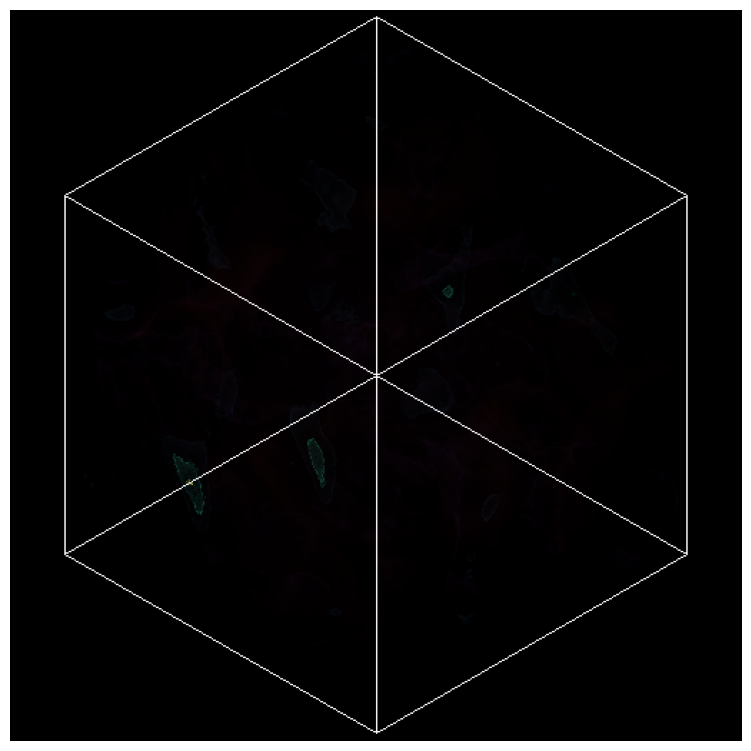

In [16]:
#%%px
# Hacky, but I think this is the only way. This is basically the content of scene.save
sigma_clip=1

#temp = test

shape = test.shape
#fig = Figure((shape[0] / 100.0, shape[1] / 100.0))
fig = plt.figure()
fig.set(dpi = 100)
fig.set_size_inches((shape[0] / 70.0, shape[1] / 70.0))
canvas = fig.canvas #yt.visualization._commons.get_canvas(fig, yt.visualization._commons.validate_image_name("Volume Render"))

ax = fig.add_axes([0, 0, 1, 1])
ax.set_axis_off()
nz = test[:, :, :3][test[:, :, :3].nonzero()]
max_val = nz.mean() + sigma_clip * nz.std()
alpha = 255 * test[:, :, 3].astype("uint8")
temp = np.clip(test[:, :, :3] / max_val, 0.0, 1.0) * 255
temp = np.concatenate([temp.astype("uint8"), alpha[..., None]], axis=-1)
temp = np.rot90(temp)
ax.imshow(temp, origin="lower")

In [17]:
for data in ds:
    mn, mx = data.all_data().quantities.extrema("EdensRel")
    print ("Min = " + str(mn) + ", Max = " + str(mx))

Min = 0.6350902754757577 dimensionless, Max = 1.399798974140129 dimensionless
Min = 0.4325351529155744 dimensionless, Max = 1.8336621864734342 dimensionless
Min = 0.12289782112928042 dimensionless, Max = 4.25674576344272 dimensionless
Min = -0.14730441717540763 dimensionless, Max = 6.580861933769458 dimensionless
Min = -0.0659187046537469 dimensionless, Max = 9.495349897283509 dimensionless
Min = -0.035639554247043854 dimensionless, Max = 20.714738241025888 dimensionless
Min = -0.03485096128367567 dimensionless, Max = 40.32385283141907 dimensionless
Min = -0.04554125784143137 dimensionless, Max = 66.66458062524332 dimensionless
Min = -0.10411594086782125 dimensionless, Max = 80.30472437332098 dimensionless
Min = -0.053361063647010834 dimensionless, Max = 101.53543166396346 dimensionless
Min = -0.07207944591339653 dimensionless, Max = 98.31720977750284 dimensionless


In [ ]:
renders = []
for data in ds:
#for i in range(len(ds) - 2, len(ds)):
#    data = ds[i]
        
    sc = yt.create_scene(data, ("boxlib", "EdensRel"))#, lens_type="perspective", )
    sc.annotate_domain(data, color=[1, 1, 1, 0.01])
    sc.annotate_grids(data, alpha=0.01)
    source = sc[0]
    source.set_field(("boxlib", "EdensRel"))
    source.set_log(True)
    #source.set_log(False)
    source.tfh.gray_opacity = False
    source.tfh.set_log(True)
    #source.tfh.set_log(False)

    av = data.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
    mn, mx = data.all_data().quantities.extrema("EdensRel")
    
    #print ("Min = " + str(mn) + ", Max = " + str(mx))
#    if (mnI < 0):
#        mn = -mn
    #   1e-20
    #mn = 10*av
    mn = 1
    if mn > mx:
        mx = 2*mn
    bounds = (mn, mx)
    #print(bounds)
    #bounds = (2*mx,10*mx)

    # Since this rendering is done in log space, the transfer function needs
    # to be specified in log space.
    tf = yt.ColorTransferFunction(np.log10(bounds))
    #tf = yt.ColorTransferFunction(bounds)

    tf.add_layers(5, colormap="arbre")

    source.tfh.tf = tf
    source.tfh.bounds = bounds

    sc.camera.zoom(0.9)
#source.tfh.plot("transfer_function.png", profile_field=("boxlib", "Edens"))
    renders.append(sc.render())
    #sc.show(sigma_clip=0.7)

yt : [INFO     ] 2022-06-16 15:54:07,039 Rendering scene (Can take a while).
yt : [INFO     ] 2022-06-16 15:54:07,048 Creating volume
yt : [INFO     ] 2022-06-16 15:54:07,870 Rendering scene (Can take a while).
yt : [INFO     ] 2022-06-16 15:54:07,881 Creating volume
yt : [INFO     ] 2022-06-16 15:54:08,763 Rendering scene (Can take a while).
yt : [INFO     ] 2022-06-16 15:54:08,774 Creating volume
yt : [INFO     ] 2022-06-16 15:54:10,054 Rendering scene (Can take a while).
yt : [INFO     ] 2022-06-16 15:54:10,084 Creating volume
yt : [INFO     ] 2022-06-16 15:54:25,888 Rendering scene (Can take a while).
yt : [INFO     ] 2022-06-16 15:54:26,049 Creating volume
yt : [INFO     ] 2022-06-16 15:57:46,634 Rendering scene (Can take a while).
yt : [INFO     ] 2022-06-16 15:57:46,772 Creating volume


In [ ]:
def animate(i):

    sigma_clip = 0.7
    
    nz = renders[i][:, :, :3][renders[i][:, :, :3].nonzero()]
    max_val = nz.mean() + sigma_clip * nz.std()
    #max_val = 5.*nz.mean()
    alpha = 255 * renders[i][:, :, 3].astype("uint8")
    temp = np.clip(renders[i][:, :, :3] / max_val, 0.0, 1.0) * 255
    #test = np.clip(renders[i][:, :, :3] / max_val, 0.0, None) * 255
    temp = np.concatenate([temp.astype("uint8"), alpha[..., None]], axis=-1)
    temp = np.rot90(temp)
    ax.imshow(temp, origin="lower")

In [ ]:
#for i in range(len(ds)):
#    print("i = " + str(i))
#    animate(i)

In [ ]:
animation = FuncAnimation(fig, animate, frames=len(renders), interval = 400)

In [ ]:
# Override matplotlib's defaults to get a nicer looking font
with rc_context({"mathtext.fontset": "stix"}):
    #animation.save("animation.mp4")
    video = animation.to_html5_video()
    html = display.HTML(video)
    display.display(html)